# Data Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

In [2]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tokenizer = AutoTokenizer.from_pretrained("facebook/nllb-200-distilled-600M")
model = AutoModelForSeq2SeqLM.from_pretrained("facebook/nllb-200-distilled-600M")

def translate(text, src_lang, tgt_lang):
    tokenizer.src_lang = src_lang
    inputs = tokenizer(text, return_tensors="pt")
    target_lang_id = tokenizer.convert_tokens_to_ids(tgt_lang)
    outputs = model.generate(**inputs, forced_bos_token_id=target_lang_id)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

print(translate("este es un modelo genial", src_lang="spa_Latn", tgt_lang="eng_Latn"))
print(translate("este  modelo genial", src_lang="spa_Latn", tgt_lang="eng_Latn"))
print(translate("este genial modelo ", src_lang="spa_Latn", tgt_lang="eng_Latn"))


/opt/miniconda3/envs/machineLearning/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 512/512 [00:00<00:00, 34660.31it/s]
The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weig

This is a great model.
This is a great model.
This great model .


In [3]:
english_file = open("data/es-en/europarl-v7.es-en.en", encoding="utf-8").read().splitlines()
spanish_file = open("data/es-en/europarl-v7.es-en.es", encoding="utf-8").read().splitlines()

In [4]:
print(english_file[0])
print(spanish_file[0])

Resumption of the session
Reanudación del período de sesiones


In [5]:


pairs = list(zip(english_file, spanish_file))

clean_pairs = []


for en, fr in pairs:
    if len(en.split()) < 3 or len(fr.split()) < 3:
        continue
    if len(en) > 300 or len(fr) > 300:
        continue
    clean_pairs.append((en, fr))

print(pairs[0])
print(clean_pairs[0])
print(clean_pairs[1])
print(clean_pairs[-1])
print(f'Originally, pairs had length {len(pairs)}')
print(f'After cleaning, pairs has length {len(clean_pairs)}')
print(f'{len(pairs) - len(clean_pairs)} pairs were removed. That is {round((len(pairs) - len(clean_pairs)) / len(pairs) * 100, 2)}% of the dataset.')

('Resumption of the session', 'Reanudación del período de sesiones')
('Resumption of the session', 'Reanudación del período de sesiones')
('I declare resumed the session of the European Parliament adjourned on Friday 17 December 1999, and I would like once again to wish you a happy new year in the hope that you enjoyed a pleasant festive period.', 'Declaro reanudado el período de sesiones del Parlamento Europeo, interrumpido el viernes 17 de diciembre pasado, y reitero a Sus Señorías mi deseo de que hayan tenido unas buenas vacaciones.')
('(The sitting was closed at 10.50 a.m.)', '(Se levanta la sesión a las 10.50 horas)')
Originally, pairs had length 1965734
After cleaning, pairs has length 1761173
204561 pairs were removed. That is 10.41% of the dataset.


In [ ]:
# # Collect all Spanish sentences
# spanish_sentences = [sp for en, sp in clean_pairs]

# # Batch translate all Spanish sentences at once - to optimize runtime
# translated_sentences = []
# batch_size = 32  # Adjust based on your GPU memory (higher = faster, but may cause OOM)

# for i in range(0, len(spanish_sentences), batch_size):
#     batch = spanish_sentences[i:i+batch_size]
#     tokenizer.src_lang = "spa_Latn"
#     inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True)
#     target_lang_id = tokenizer.convert_tokens_to_ids("eng_Latn")
#     outputs = model.generate(**inputs, forced_bos_token_id=target_lang_id, max_length=200)
#     batch_translations = tokenizer.batch_decode(outputs, skip_special_tokens=True)
#     translated_sentences.extend(batch_translations)
#     print(f"Processed batch {i//batch_size + 1}/{(len(spanish_sentences) + batch_size - 1)//batch_size}")

# X = []
# y = []
# for en, translated_sp in zip([en for en, sp in clean_pairs], translated_sentences):
#     X.append(en)
#     y.append(0)
#     X.append(translated_sp)
#     y.append(1)

# X = np.array(X)
# y = np.array(y)
# print(X.shape)
# print(y.shape)
# for i in range(5):
#     print(X[i], "->", y[i])

KeyboardInterrupt: 

In [6]:
X_temp = []
y_temp = []
count = 0
for en, sp in clean_pairs:
    if count >= 20:  # Limit to first 1000 pairs for now
        break
    # print(count)
    X_temp.append(en)
    y_temp.append(0)
    print(en)
    print(0)
    val = translate(sp, src_lang="spa_Latn", tgt_lang="eng_Latn")
    X_temp.append(val)
    y_temp.append(1)
    print(sp)
    print(val)
    print(1)
    count += 1
    print("-----")
    
    
X_temp = np.array(X_temp)
y_temp = np.array(y_temp)
print(X_temp.shape)
print(y_temp.shape)
for i in range(5):
    print(X_temp[i], "->",  y_temp[i])


Resumption of the session
0
Reanudación del período de sesiones
The Commission shall adopt a decision on the extension of the period of the meetings.
1
-----
I declare resumed the session of the European Parliament adjourned on Friday 17 December 1999, and I would like once again to wish you a happy new year in the hope that you enjoyed a pleasant festive period.
0
Declaro reanudado el período de sesiones del Parlamento Europeo, interrumpido el viernes 17 de diciembre pasado, y reitero a Sus Señorías mi deseo de que hayan tenido unas buenas vacaciones.
I declare the European Parliament's session, which was interrupted on Friday 17 December, to have resumed and I wish you a good holiday.
1
-----
Although, as you will have seen, the dreaded 'millennium bug' failed to materialise, still the people in a number of countries suffered a series of natural disasters that truly were dreadful.
0
Como todos han podido comprobar, el gran "efecto del año 2000" no se ha producido. En cambio, los ciud

KeyboardInterrupt: 

In [7]:
X = []
y = []
count = 0
for en, sp in clean_pairs:
    if count >= 20: 
        break
    print(count)
    X.append(en)
    y.append(0)
    # print(en)
    # print(0)
    
    X.append(translate(sp, src_lang="spa_Latn", tgt_lang="eng_Latn"))
    y.append(1)
    # print(sp)
    # print(1)
    count += 1
    
    
X = np.array(X)
y = np.array(y)
print(X.shape)
print(y.shape)
for i in range(5):
    print(X[i], "->",  y[i])


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
(40,)
(40,)
Resumption of the session -> 0
The Commission shall adopt a decision on the extension of the period of the meetings. -> 1
I declare resumed the session of the European Parliament adjourned on Friday 17 December 1999, and I would like once again to wish you a happy new year in the hope that you enjoyed a pleasant festive period. -> 0
I declare the European Parliament's session, which was interrupted on Friday 17 December, to have resumed and I wish you a good holiday. -> 1
Although, as you will have seen, the dreaded 'millennium bug' failed to materialise, still the people in a number of countries suffered a series of natural disasters that truly were dreadful. -> 0


In [8]:
data = pd.DataFrame({"text": X_temp, "label": y_temp})
print(data.head())

                                                text  label
0                          Resumption of the session      0
1  The Commission shall adopt a decision on the e...      1
2  I declare resumed the session of the European ...      0
3  I declare the European Parliament's session, w...      1
4  Although, as you will have seen, the dreaded '...      0


## Are there punctuation patterns per label group

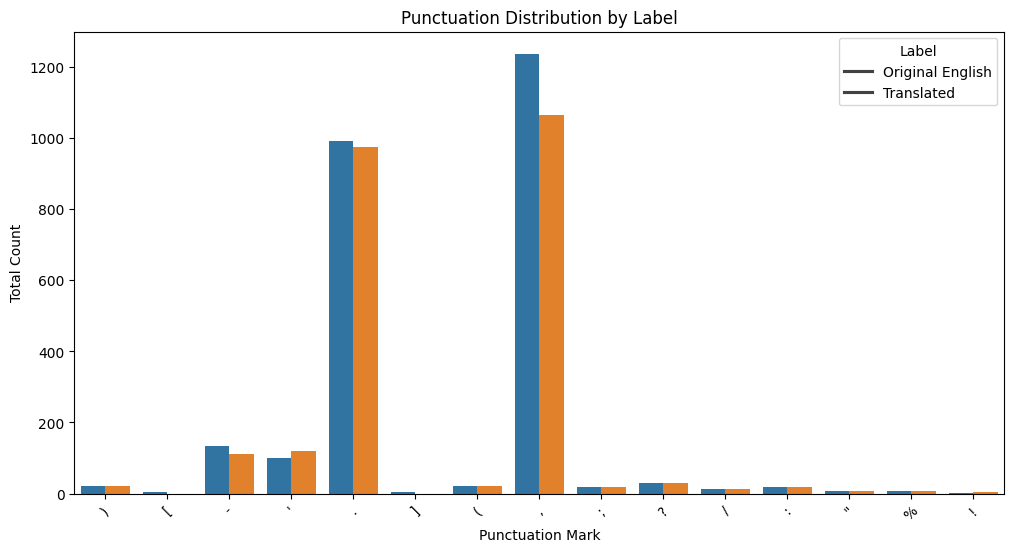

In [16]:
import string

# Define punctuation marks to analyze
punctuations = string.punctuation

# Function to count punctuation in a text
def count_punct(text):
    counts = {}
    for char in text:
        if char in punctuations:
            counts[char] = counts.get(char, 0) + 1
    return counts

# Apply to all texts
data['punct_counts'] = data['text'].apply(count_punct)

# Aggregate counts per label
label_0_counts = {}
label_1_counts = {}

for idx, row in data.iterrows():
    if row['label'] == 0:
        for punct, count in row['punct_counts'].items():
            label_0_counts[punct] = label_0_counts.get(punct, 0) + count
    else:
        for punct, count in row['punct_counts'].items():
            label_1_counts[punct] = label_1_counts.get(punct, 0) + count

# Get all unique punctuation marks
all_punct = set(label_0_counts.keys()) | set(label_1_counts.keys())

# Prepare data for plotting
punct_df = pd.DataFrame({
    'punctuation': list(all_punct),
    'label_0': [label_0_counts.get(p, 0) for p in all_punct],
    'label_1': [label_1_counts.get(p, 0) for p in all_punct]
})

# Melt for easier plotting
punct_df_melted = punct_df.melt(id_vars='punctuation', var_name='label', value_name='count')

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=punct_df_melted, x='punctuation', y='count', hue='label')
plt.title('Punctuation Distribution by Label')
plt.xlabel('Punctuation Mark')
plt.ylabel('Total Count')
plt.xticks(rotation=45)
plt.legend(title='Label', labels=['Original English', 'Translated'])
plt.show()

In [17]:
# Use the larger dataset for more meaningful analysis
data_large = pd.DataFrame({"text": X, "label": y})

# Compute various features
data_large['text_length'] = data_large['text'].apply(len)
data_large['word_count'] = data_large['text'].apply(lambda x: len(x.split()))
data_large['punct_count'] = data_large['text'].apply(lambda x: sum(1 for c in x if c in string.punctuation))
data_large['unique_words'] = data_large['text'].apply(lambda x: len(set(x.lower().split())))
data_large['lexical_diversity'] = data_large['unique_words'] / data_large['word_count'].replace(0, 1)  # Avoid division by zero

# Display summary statistics by label
summary_stats = data_large.groupby('label')[['text_length', 'word_count', 'punct_count', 'unique_words', 'lexical_diversity']].describe()
print(summary_stats)

      text_length                                                        \
            count     mean        std   min    25%    50%    75%    max   
label                                                                     
0          1000.0  131.666  64.777686  14.0  79.00  124.0  176.0  300.0   
1          1000.0  126.248  64.058364  17.0  78.75  119.5  169.0  760.0   

      word_count          ... unique_words       lexical_diversity            \
           count    mean  ...          75%   max             count      mean   
label                     ...                                                  
0         1000.0  22.267  ...         26.0  46.0            1000.0  0.911932   
1         1000.0  21.236  ...         24.0  40.0            1000.0  0.903309   

                                                         
            std       min       25%       50%  75%  max  
label                                                    
0      0.079033  0.630435  0.857143  0.921538  1.

In [ ]:
# Visualize distributions
features = ['text_length', 'word_count', 'punct_count', 'unique_words', 'lexical_diversity']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    print(feature)
    sns.boxplot(data=data_large, x='label', y=feature, ax=axes[i])
    axes[i].set_title(f'Distribution of {feature.replace("_", " ").title()} by Label')
    axes[i].set_xlabel('Label')
    axes[i].set_ylabel(feature.replace("_", " ").title())

# Hide the last empty subplot if any
if len(features) < len(axes):
    for j in range(len(features), len(axes)):
        axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import ttest_ind

# Perform t-tests for each feature
print("T-test results for differences between labels:")
for feature in features:
    group_0 = data_large[data_large['label'] == 0][feature]
    group_1 = data_large[data_large['label'] == 1][feature]
    t_stat, p_value = ttest_ind(group_0, group_1)
    print(f"{feature}: t-statistic = {t_stat:.3f}, p-value = {p_value:.3f}")
    if p_value < 0.05:
        print("  -> Significant difference (p < 0.05)")
    else:
        print("  -> No significant difference (p >= 0.05)")
    print()